### Exercise 3 (Hard)

Look at the [WikiArt dataset](https://github.com/cs-chan/ArtGAN/blob/master/WikiArt%20Dataset/README.md). Pick a task of your choice among artist, genre, and style classification. Design, implement, and evaluate a model for this task. Consider starting by reusing the simple model we devised above, and expand from it using more advanced architectures. You can use pre-trained models or implement your own approach from scratch, or both.

In [1]:
# IMPORTS #

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import os, random
import pandas as pd
from torchmetrics.classification import MulticlassF1Score
from datetime import datetime

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set_theme('notebook', style='whitegrid')

## Progress bar
from tqdm.notebook import tqdm

import torch
print(torch.__version__)


torch.manual_seed(42) # Setting the seed
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu") # setting device agnostic device

2.4.1+cu124


#### Preprocessing  

In [2]:
# Data exploration

# train_df = pd.read_csv('./data/wikiart/wikiart_csv/style_train.csv', header=None)
# total_train = len(train_df)
# train_df.columns = ["train_paths", "train_labels"]
# train_count = train_df["train_labels"].value_counts(sort=False).values
# # train_df = train_df.apply(lambda x: x / 57023 * 100)

# val_df = pd.read_csv('./data/wikiart/wikiart_csv/style_val.csv', header=None)
# total_val = len(val_df)
# val_df.columns = ["val_paths", "val_labels"]
# val_count = val_df["val_labels"].value_counts().values
# # val_df = val_df.apply(lambda x: x / 24421 * 100)

# # Weighting to balance the skewed classes
# train_weights = total_train / train_count
# val_weights = total_val / val_count
# print(train_weights)
# print(val_weights)

# train_weighted = [train_weights[label] for label in train_df["train_labels"].values] # weights lookup for each label value in the whole dataset
# val_weighted = [val_weights[label] for label in val_df["val_labels"].values]

# # Pytorch sampler
# train_sampler = WeightedRandomSampler(train_weighted, num_samples=total_train)
# val_sampler = WeightedRandomSampler(val_weighted, num_samples=total_val)

In [3]:
class WikiArtImageDataset(Dataset):
    def __init__(self, txt, csv_file, img_dir, transform=None, fraction: float = 1.0):
        self.classes = pd.read_csv(txt, sep=" ", header=None)
        self.annotations = pd.read_csv(csv_file, header=None)
        print(len(self.annotations))
        self.annotations.columns = ["Paths", "Labels"]
        if fraction < 1.0:
            self.annotations = self.annotations.groupby("Labels", group_keys=False).apply(lambda x: x if len(x) < 10 else x.sample(frac=fraction))
            print(len(self.annotations))

        # print(self.annotations)
        self.img_dir = img_dir
        self.transform = transform
        # ENCODING STRINGS IN DICT 
        self.enc = {name: id for id, name in self.classes.itertuples(index=False)}
        # Create a reverse mapping for integer labels back to string labels
        self.dec = {idx: label for label, idx in self.enc.items()}
                                                                         
    def __len__(self):
        return len(self.annotations)

    # Applied each time batches are returned by DataLoader, executing all the "preprocessing"
    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path).convert("RGB")
        label = self.annotations.iloc[index, 1]
        # Convert string label to integer
        if self.transform:
            image = self.transform(image)

        return image, label
    # Function to adjust the weighted sampler to subsets of the dataset 

    def get_sampler (self):
        df = self.annotations
        length = len(df)
        count = df["Labels"].value_counts(sort=False).values
        # val_df = val_df.apply(lambda x: x / 24421 * 100)

        # Weighting to balance the skewed classes
        weights = length / count

        weighted_samples = [weights[label] for label in df["Labels"].values] # weights lookup for each label value in the whole dataset

        # Pytorch sampler
        sampler = WeightedRandomSampler(weighted_samples, num_samples=length, replacement=True)

        return sampler

# Paths to the data
classes = './data/wikiart/wikiart_csv/style_class.txt'
train_csv = './data/wikiart/wikiart_csv/style_train.csv'  # Path to your CSV file
val_csv = './data/wikiart/wikiart_csv/style_val.csv'  # Path to your CSV file                                                                                                                                                                                                                                                                                                                                                       
img_dir = './data/wikiart/wikiart_img/'       # Directory with all the images

# Define image transformations
# (ex.: trying to use padding instead of resizing)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop((192, 192)),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.25, 0.25, 0.25], inplace=True)
   ])


# Create the datasets
train_dataset = WikiArtImageDataset(txt=classes, 
                                    csv_file=train_csv, 
                                    img_dir=img_dir,
                                    fraction=0.05, 
                                    transform=transform) 
val_dataset =   WikiArtImageDataset(txt=classes, 
                                    csv_file=val_csv, 
                                    img_dir=img_dir,
                                    fraction=0.05, 
                                    transform=transform)

# Create DataLoader for train and validation datasets
train_sampler = train_dataset.get_sampler()
val_sampler = val_dataset.get_sampler()
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size,sampler=train_sampler, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, sampler=val_sampler, pin_memory=True)

# Example: Iterate through the training data
images, labels = next(iter(train_loader))
print(f"Train - images shape: {images.shape, type(images)}, labels shape: {labels.shape}")

# Example: Iterate through the validation data
images, labels = next(iter(val_loader))
print(f"Validation - images shape: {images.shape, type(images)}, labels shape: {labels.shape}")

57023
2852
24421
1222


C:\Users\valen.DESKTOP-4L65KSL\AppData\Local\Temp\ipykernel_14104\879006960.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.annotations = self.annotations.groupby("Labels", group_keys=False).apply(lambda x: x if len(x) < 10 else x.sample(frac=fraction))
C:\Users\valen.DESKTOP-4L65KSL\AppData\Local\Temp\ipykernel_14104\879006960.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.annotations = 

Train - images shape: (torch.Size([64, 3, 192, 192]), <class 'torch.Tensor'>), labels shape: torch.Size([64])
Validation - images shape: (torch.Size([64, 3, 192, 192]), <class 'torch.Tensor'>), labels shape: torch.Size([64])


#### Model definition

In [4]:
class CustomCNN(nn.Module):
    def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 6, 5)
            self.pool = nn.MaxPool2d(2, 2)
            self.conv2 = nn.Conv2d(6, 16, 5)
            self.fc1 = nn.Linear(44944, 120)
            self.fc2 = nn.Linear(120, 84)
            self.fc3 = nn.Linear(84, 27)

    def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1) # flatten all dimensions except batch
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x
        

In [5]:
# model_0 = CustomCNN() 
model_01 = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Freeze the layers except the last layer
for param in model_01.parameters():
    param.requires_grad = False

# Add a final layer (head) which we are gonna train while matching the number of classes
num_features = model_01.fc.in_features
num_classes = len(train_dataset.enc)
model_01.fc = nn.Linear(num_features, num_classes)

# Loading a checpoint if needed
checkpoint = None #torch.load(f="models/Resnet34_wikiart_checkpoint.pth") 
if checkpoint: model_01.fc.state_dict(checkpoint['fc_state_dict'])

torch.backends.cudnn.benchmark = True
# model_0.to(device)
model_01.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Training loop

In [6]:
def train (train_data: torch.Tensor, 
           val_data: torch.Tensor, 
           loss_fn, 
           opt: optim.Optimizer, 
           model: nn.Module, 
           device,
           epochs: int = 10, 
           scaler = None, 
           lr_scheduler=None,
           f1=None):
    
    for epoch in range(epochs): 
        start = torch.cuda.Event(enable_timing=True)
        start.record() 
        model.train()

        epoch_loss = 0 
        correct = 0
        total = 0
        num_batch = 0

        for images, labels in train_data:
            images, labels = images.to(device), labels.to(device)
            num_batch += 1
            opt.zero_grad()
            if scaler:
                with torch.amp.autocast("cuda"):
                    logits = model(images)
                    loss = loss_fn(logits, labels)

                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                logits = model(images)
                loss = loss_fn(logits, labels)

                loss.backward()
                opt.step()
                
            epoch_loss += loss.item()
            
            label_pred = torch.softmax(logits, dim=1).argmax(dim=1)
            correct += (label_pred == labels).sum().item()
            total += labels.size(0)

        train_loss_rate = epoch_loss / len(train_data)
        train_accuracy = correct * 100 / total

        model.eval()

        val_epoch_loss = 0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []

        with torch.inference_mode():
            for val_image, val_label in val_data:
                val_image, val_label = val_image.to(device), val_label.to(device)

                val_output = model(val_image)
                val_loss = loss_fn(val_output, val_label)
                val_epoch_loss += val_loss.item()

                val_pred = torch.softmax(val_output, dim=1).argmax(dim=1)
                val_correct += (val_pred == val_label).sum().item()
                val_total += val_label.size(0)
                if f1: 
                    all_preds.append(val_pred)
                    all_labels.append(val_label)
        
        val_loss_rate = val_epoch_loss / len(val_data)
        val_accuracy = val_correct * 100 / val_total
        if f1:
            all_preds = torch.concat(all_preds)
            all_labels = torch.concat(all_labels)
            f1_score = f1(all_preds, all_labels)
        else:
            f1_score = 0.0
        if lr_scheduler: lr_scheduler.step()
        end = torch.cuda.Event(enable_timing=True)
        end.record()
        torch.cuda.synchronize()  # Waits for everything to finish running on the GPU
        print(f"Epoch {epoch+1}/{epochs} \n",
              f"    Train Loss: {train_loss_rate:.4f}, Train Accuracy: {train_accuracy:.2f}%",
              f"    Val Loss: {val_loss_rate:.4f}, Val Accuracy: {val_accuracy:.2f}%, F1: {f1_score:.4f}")
        
        print(f"GPU time: {start.elapsed_time(end)/1000/60:.3f}m at local time {datetime.now().strftime('%H:%M:%S')} \n\n")  # Milliseconds to seconds

#### Training prep + instantiation

In [ ]:
loss = torch.nn.CrossEntropyLoss()
opt = optim.AdamW(params=model_01.fc.parameters(), 
                 lr=0.001)
if checkpoint: opt.load_state_dict(checkpoint["optimizer_state_dict"])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer=opt,
                                                 T_max=20)
scaler = torch.amp.GradScaler("cuda")  # Gradient scaler for GPU optimization

multi_f1 = MulticlassF1Score(num_classes=27).to(device)
epochs = checkpoint["epoch"] if checkpoint else 10


try:
    train(train_loader, val_loader, loss, opt, model_01, scaler=scaler, lr_scheduler=scheduler, device=device, epochs=epochs)
except:
    pass
# finally:
#     torch.save({
#     'fc_state_dict': model_01.fc.state_dict(),
#     'optimizer_state_dict': opt.state_dict(),
#     'epoch': 20,
#     # ... any other states you want to save
#      }, 'models/Resnet34_wikiart_checkpoint.pth')

Epoch 1/10 
     Train Loss: 2.9899, Train Accuracy: 15.99%     Val Loss: 2.8071, Val Accuracy: 21.60%, F1: 0.0000
GPU time: 2.037m at local time 02:47:06 


Epoch 2/10 
     Train Loss: 2.2914, Train Accuracy: 38.53%     Val Loss: 2.4002, Val Accuracy: 27.41%, F1: 0.0000
GPU time: 1.846m at local time 02:48:57 




#### Prediction example

True Label: Art_Nouveau
Predicted Label: Abstract_Expressionism
Model Confidence: 0.1189


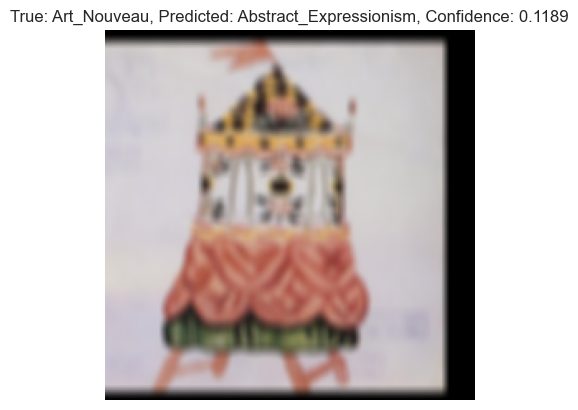

In [12]:
# Get a single batch from the validation loader
model_01.eval()  # Set the model to evaluation mode
images, true_labels = next(iter(val_loader))

images = images.to(device)
true_labels = true_labels.to(device)

# Perform a forward pass to get predictions
with torch.inference_mode():
    outputs = model_01(images)
    probabilities = F.softmax(outputs, dim=1)

# Get the predicted label and confidence
predicted_labels = torch.argmax(outputs, 1)
confidence, _ = torch.max(probabilities, 1)

# Randomly select an index for the image to display
index = random.randint(0, images.size(0) - 1)
image = images[index].cpu().permute(1, 2, 0).numpy()  # Convert to HxWxC format for plotting
true_label = true_labels[index].item()
predicted_label = predicted_labels[index].item()
confidence_score = confidence[index].item()

# Convert the label indexes back to string labels using the dataset's index_to_label dictionary
true_label_str = val_dataset.dec[true_label]
predicted_label_str = val_dataset.dec[predicted_label]

# Print the true label, predicted label, and confidence
print(f"True Label: {true_label_str}")
print(f"Predicted Label: {predicted_label_str}")
print(f"Model Confidence: {confidence_score:.4f}")

# Optionally, display the image
plt.imshow(image)
plt.title(f"True: {true_label_str}, Predicted: {predicted_label_str}, Confidence: {confidence_score:.4f}")
plt.axis('off')
plt.show()